# 04 — Product Analysis: Segments, Routing, Cold Start, and the A/B Test

`03_models.ipynb` answered "which model has the best offline ranking
metric". This notebook asks the product question: **for which users does
which strategy actually work, what would we ship, and how would we check
it in production?**

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

from src import data as D
from src import evaluation as E
from src import pipeline as P

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)
FIG_DIR = "../reports/figures"
TABLE_DIR = "../reports/tables"
K = P.K

## 1. Rebuild validation and test recommendations

The routing strategy is *chosen* using validation data only, then evaluated
once on test — the same discipline as the hyperparameter search in `02`. So
this notebook fits models twice: on train (for validation-time choices) and
on train+val (for the test-time numbers), exactly mirroring `02` and `03`.

In [2]:
users, movies, df, user_id_to_idx, item_id_to_idx = P.load_and_split("../data")
n_users = df["user_idx"].nunique()

# validation-phase models (train only) -- used to choose the routing strategy
fitted_val = P.fit_all_models(df, movies, item_id_to_idx, ["train"])
seen_val = D.get_seen(df, ["train"])
truth_val = D.get_truth(df, "val", threshold=D.RELEVANT_RATING_THRESHOLD)
users_val = list(truth_val.keys())
rec_val = P.recommend_all(fitted_val, users_val, seen_val, K)

# test-phase models (train+val) -- used for the final, one-time numbers
fitted_test = P.fit_all_models(df, movies, item_id_to_idx, ["train", "val"])
seen_test = D.get_seen(df, ["train", "val"])
truth_test = D.get_truth(df, "test", threshold=D.RELEVANT_RATING_THRESHOLD)
users_test = list(truth_test.keys())
rec_test = P.recommend_all(fitted_test, users_test, seen_test, K)
print("done")

done


## 2. User-history segments

`01_data_and_eda.ipynb` showed MovieLens-1M has essentially no *absolute*
cold-start users (everyone has 20+ ratings) but a heavy-tailed activity
distribution. Segments are therefore defined by **quartiles of each user's
history size at the moment of prediction** (train count when predicting
validation; train+val count when predicting test) — a *relative* notion of
"how much do we know about this person so far", recomputed separately for
each phase so the segment boundaries always reflect that phase's own
distribution.

In [3]:
train_counts = df[df.split == "train"].groupby("user_idx").size().to_dict()
trainval_counts = df[df.split.isin(["train", "val"])].groupby("user_idx").size().to_dict()

edges_val = np.quantile(list(train_counts.values()), [0.25, 0.5, 0.75])
edges_test = np.quantile(list(trainval_counts.values()), [0.25, 0.5, 0.75])
labels = ["sparse (Q1)", "low (Q2)", "medium (Q3)", "high (Q4)"]
print("Validation-phase cutoffs (train interactions):", edges_val)
print("Test-phase cutoffs (train+val interactions):   ", edges_test)

seg_val = E.segment_of_users(train_counts, edges_val, labels)
seg_test = E.segment_of_users(trainval_counts, edges_test, labels)

Validation-phase cutoffs (train interactions): [ 31.  67. 146.]
Test-phase cutoffs (train+val interactions):    [ 37.  82. 177.]


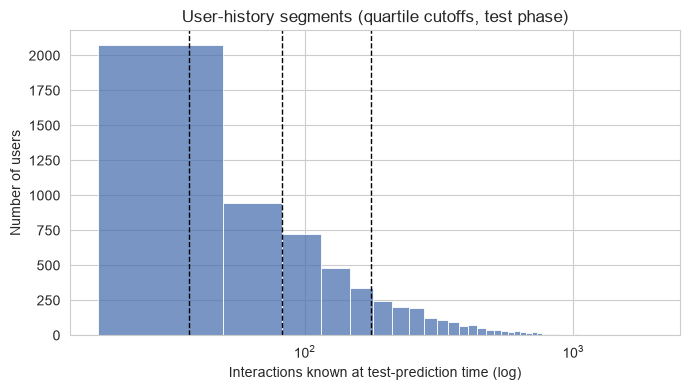

In [4]:
plt.figure(figsize=(7, 4))
sns.histplot(list(trainval_counts.values()), bins=60, color="#4C72B0")
for e in edges_test:
    plt.axvline(e, color="black", linestyle="--", linewidth=1)
plt.xscale("log")
plt.xlabel("Interactions known at test-prediction time (log)")
plt.ylabel("Number of users")
plt.title("User-history segments (quartile cutoffs, test phase)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/segment_cutoffs.png", dpi=150)
plt.show()

## 3. Model quality by segment

In [5]:
seg_table_val = pd.DataFrame(E.segment_metrics_table(rec_val, truth_val, seg_val, K))
seg_table_test = pd.DataFrame(E.segment_metrics_table(rec_test, truth_test, seg_test, K))
seg_table_val.to_csv(f"{TABLE_DIR}/segment_metrics_val.csv", index=False)
seg_table_test.to_csv(f"{TABLE_DIR}/segment_metrics_test.csv", index=False)

pivot_test = seg_table_test.pivot(index="model", columns="segment", values="NDCG@K")[labels]
pivot_test.round(4)

segment,sparse (Q1),low (Q2),medium (Q3),high (Q4)
model,,,,
ALS,0.1010,0.0697,0.0705,0.1214
BPR,0.0850,0.0552,0.0539,0.0720
Content-Based,0.0175,0.0162,0.0150,0.0194
Hybrid,0.0937,0.0861,0.0792,0.1505
Item-kNN,0.0919,0.0857,0.0823,0.1558
Popularity,0.0359,0.0465,0.0700,0.1420


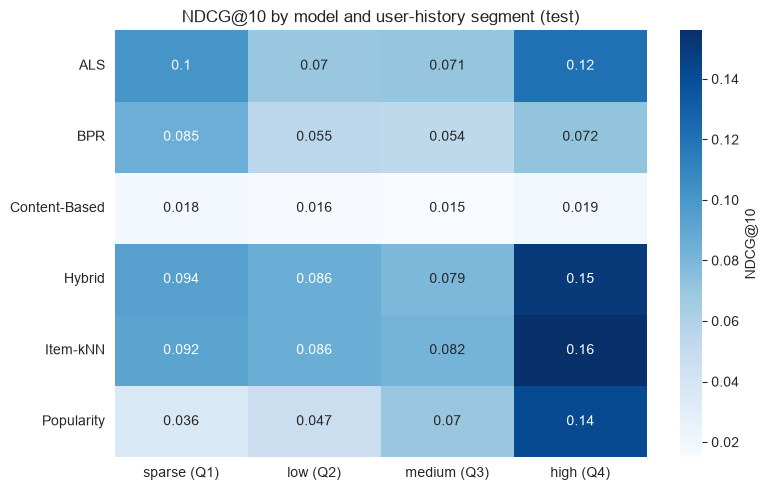

In [6]:
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_test.round(3), annot=True, cmap="Blues", cbar_kws={"label": "NDCG@10"})
plt.title("NDCG@10 by model and user-history segment (test)")
plt.ylabel(""); plt.xlabel("")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/segment_heatmap.png", dpi=150)
plt.show()

**What the segments show (test set):**

- **Sparse (Q1)** users are best served by **ALS** (NDCG@10 highest in this segment) — a factorization model generalizes better than a similarity-count-based Item-kNN when a user has few ratings to anchor on.
- **Low/Medium (Q2–Q3)** users are best served by **Item-kNN** (and the Hybrid, which is built on Item-kNN, is essentially tied) — with more history, direct item-to-item co-rating patterns become reliable.
- **High (Q4) / power users** are also best served by **Item-kNN** — but Popularity is a surprisingly close second here (clearly ahead of ALS, BPR and even the Hybrid in this one segment), because power users have rated so much that even a non-personalized popular-movies list has a good chance of overlapping with their large relevant set. Popularity's advantage disappears in every other segment.
- **Content-Based is the weakest model in every single segment**, including the sparsest one. The common hypothesis "content-based helps most when history is short" is **not supported by this data** — genre similarity alone does not predict *which* specific movie a user will rate ≥4 next, regardless of how much or little history they have.

## 4. Routing strategy: pick the best model per segment on validation, test it once on test

In [7]:
router = E.build_router(rec_val, truth_val, seg_val, K)
print("Routing strategy chosen on VALIDATION (segment -> model):")
for seg in labels:
    print(f"  {seg:12s} -> {router.get(seg)}")

Routing strategy chosen on VALIDATION (segment -> model):
  sparse (Q1)  -> ALS
  low (Q2)     -> Hybrid
  medium (Q3)  -> Item-kNN
  high (Q4)    -> Item-kNN


In [8]:
routed_test = E.apply_router(router, rec_test, seg_test, users_test)
router_metrics = E.full_evaluation(
    routed_test, truth_test, fitted_test["catalog_items"], fitted_test["pop_count"],
    fitted_test["n_train_interactions"], fitted_test["feature_matrix"], fitted_test["item_pos"], K,
)

comparison = pd.DataFrame(P.evaluate_all(rec_test, truth_test, fitted_test, K)).set_index("model")
comparison.loc["Routing strategy"] = router_metrics
comparison = comparison.drop(columns=[c for c in comparison.columns if c == "n_users"])
comparison.sort_values("NDCG@K", ascending=False).round(4)

,Recall@K,Precision@K,MAP@K,NDCG@K,Coverage@K,Novelty@K,Diversity@K,AvgPopularity@K
model,,,,,,,,
Routing strategy,0.0875,0.0808,0.0524,0.1065,0.2143,9.1134,0.6178,1681.6792
Item-kNN,0.0819,0.0795,0.0514,0.1042,0.1270,8.9366,0.6346,1846.6839
Hybrid,0.0830,0.0785,0.0500,0.1026,0.1441,9.0434,0.5809,1733.8412
ALS,0.0813,0.0684,0.0432,0.0907,0.3555,9.6677,0.6020,1236.9680
Popularity,0.0477,0.0623,0.0349,0.0739,0.0362,8.4986,0.6451,2378.5814
BPR,0.0641,0.0479,0.0304,0.0664,0.7623,11.1328,0.4844,620.0075
Content-Based,0.0169,0.0130,0.0069,0.0170,0.8325,13.1368,0.0851,258.7722


**The routing strategy is the best offline result in the entire project**:
higher Recall@10, MAP@10 and NDCG@10 than every single model *and* better
catalog coverage than any collaborative model (because it draws from four
different models across segments instead of one). The margin over the
single best model (Item-kNN) is modest — a few points of NDCG, not a
step change — so this should be read as "worth an online test", not as a
guaranteed production win; see Section 6.

In [9]:
import json
with open(f"{TABLE_DIR}/router_summary.json", "w") as f:
    json.dump({
        "router": router,
        "router_test_metrics": router_metrics,
        "edges_val": edges_val.tolist(),
        "edges_test": edges_test.tolist(),
    }, f, indent=2, default=float)
print("saved")

saved


## 5. Cold start

**User cold start.** MovieLens-1M is pre-filtered to users with 20+ ratings
(`01_data_and_eda.ipynb`), so genuine new-user cold start (0 interactions)
cannot be observed or evaluated in this dataset — every "sparse" user here
still has at least 14 training interactions. In a real product, a
brand-new user has none of that, and none of the models compared here would
have anything to rank on: Item-kNN, ALS and the Hybrid all require at least
one training interaction. The only strategies usable at true zero-history
are **Popularity** and an onboarding flow (asking for a few genre/title
preferences up front, which is exactly what would let a **Content-Based**
score be computed from interaction zero). This project's segment analysis
therefore describes "users with less history than others", not "brand-new
users" — a real limitation of using MovieLens-1M for this question.

**Item cold start.** This is directly observable: ~7.8% of rated movies
have fewer than 5 ratings, and 177 catalog movies (out of 3,883) have never
been rated at all (`01_data_and_eda.ipynb`). Collaborative and factorization
models (Item-kNN, ALS, BPR) cannot recommend an item with no interaction
history — by construction, this project's candidate catalog for every model
is restricted to items observed in train (`02_evaluation_setup.ipynb`), so
new items are silently excluded from every model's candidate set here.
Content-Based is the only model in this comparison that can score a new
item on day one, from its genres and release year alone, before any user
has interacted with it.

**Production implication:** a real system would not pick one model for
everyone — it would route new users to popularity/onboarding-content, keep
new items visible via a content-based or explicit "new releases" slot, and
let the collaborative/hybrid models take over once enough interaction data
exists. This is the same logic behind the segment-based routing strategy
above, extended to the boundary case Q1 doesn't actually cover (zero
history), which is not observable in this dataset.

## 6. Product decision

Based only on what was actually measured above:

1. **Default model:** ship **Item-kNN** as the single-model default — it is
   the strongest or tied-strongest model in three of four segments and the
   simplest of the competitive options (no factorization training,
   trivially explainable as "people who liked what you liked also liked...").
2. **Routing, as a next step, not day one:** the segment-based router
   (Section 4: ALS for the sparsest-history quartile, Item-kNN or its
   Hybrid variant for the rest) beat every single
   model on every offline ranking metric *and* on coverage. The gain over
   Item-kNN alone is modest, so it is a reasonable **candidate for an A/B
   test**, not a justification to ship four models on day one — the added
   engineering complexity (four models in production, a routing layer, more
   monitoring surface) should be weighed against a small measured offline
   gain, which is exactly what an online test is for.
3. **Popularity as a fallback, not a segment winner:** Popularity never wins
   a segment outright here, but it is cheap, always available (no training
   data needed at all), and a sensible fallback when a model has no
   candidates to score (e.g., a genuinely new user with zero history, which
   this dataset cannot itself test).
4. **Diversity/exploration trade-off:** the default (Item-kNN) has the
   lowest catalog coverage (12.7%) of any personalized model and leans on
   already-popular items (avg. recommended popularity ≈ 1,850 interactions,
   `03_models.ipynb`). If the product goal includes catalog health /
   long-tail exposure and not just next-click accuracy, a small blended
   slot of content-based or higher-novelty recommendations (e.g., 1–2 of
   the 10 slots) is a deliberate accuracy-for-diversity trade a product
   team could choose to make — this project does not have the data to say
   whether users would tolerate that trade, which is again a question for
   an online test.
5. **What this offline analysis cannot tell us:** whether any of this
   changes actual engagement. Offline Recall/NDCG measure whether a model
   *would have* ranked a movie the user *happened to rate ≥4 later* near the
   top — not whether showing it changes what the user does. That gap is
   exactly what Section 7's A/B test is designed to close.

## 7. A/B test design: baseline → routing strategy

This is a **design**, not a simulated result. MovieLens has no CTR or
watch-time data, so no real baseline conversion rate exists to plug in —
the sample-size table below is an explicit **sensitivity/scenario
analysis**, not a forecast.

**Hypothesis.** Routing users to a segment-appropriate model (Section 4)
increases engagement with recommended movies compared to today's baseline
policy, without degrading recommendation latency or over-concentrating
recommendations on a handful of titles.

**Randomization unit.** User (not session or impression) — recommendation
quality compounds across a user's sessions, and per-user randomization
avoids a single user seeing both arms.

**Control.** The current production recommendation policy (in this
project's terms: a single default model, e.g. Item-kNN, for every user).

**Treatment.** The segment-based routing strategy from Section 4 (each user
is assigned a history-size segment from their live interaction count, then
served that segment's best validation-selected model).

**Primary metric.** *Recommendation click-through rate* — clicks (or
play-starts) on a recommended movie divided by recommendation impressions.
It is the direct, short-latency behavioral analogue of the offline ranking
metrics (Recall/NDCG) used in this project, and is standard for a
recommendation-surface test.

**Secondary metrics.**
- Play-through / completion rate of clicked recommendations (does the click convert into real engagement, not just a curiosity click).
- Watch time attributable to recommended titles.
- Save / add-to-list rate on recommended titles.

**Guardrail metrics.**
- Recommendation-serving latency (p50/p95) — routing adds a segment lookup and, for sparse users, an ALS scoring call instead of an Item-kNN one.
- Catalog concentration of what is actually shown (e.g. share of impressions going to the top 100 titles) — a routing strategy should not silently regress into being popularity-only for some segment.
- Overall session length / bounce rate — a guard against a regression in the broader experience, not just the recommendation module.

**Sample size / MDE sensitivity analysis.** Two-sided two-proportion z-test,
80% power, α=0.05, on primary-metric CTR. Required users **per arm** for a
few illustrative baseline CTR and relative-MDE combinations:

In [10]:
def required_n_per_arm(p1, relative_mde, alpha=0.05, power=0.80):
    p2 = p1 * (1 + relative_mde)
    z_alpha = norm.ppf(1 - alpha / 2)
    z_beta = norm.ppf(power)
    pooled = (p1 + p2) / 2
    numerator = (z_alpha * np.sqrt(2 * pooled * (1 - pooled)) + z_beta * np.sqrt(p1*(1-p1) + p2*(1-p2))) ** 2
    return numerator / (p2 - p1) ** 2

rows = []
for p1 in [0.05, 0.10, 0.15]:
    for mde in [0.05, 0.10, 0.20]:
        n = required_n_per_arm(p1, mde)
        rows.append({"baseline_CTR": p1, "relative_MDE": mde, "target_CTR": round(p1 * (1 + mde), 4),
                     "users_per_arm": int(np.ceil(n))})
sensitivity = pd.DataFrame(rows)
sensitivity

,baseline_CTR,relative_MDE,target_CTR,users_per_arm
0,0.05,0.05,0.0525,122124
1,0.05,0.10,0.0550,31234
2,0.05,0.20,0.0600,8158
3,0.10,0.05,0.1050,57763
4,0.10,0.10,0.1100,14751
5,0.10,0.20,0.1200,3841
6,0.15,0.05,0.1575,36310
7,0.15,0.10,0.1650,9257
8,0.15,0.20,0.1800,2402


Reading this as a scenario table, not a forecast: detecting a **5% relative**
lift on a 10% baseline CTR needs roughly 58,000 users per arm; a **20%
relative** lift on the same baseline needs roughly 3,800 per arm. The real
required sample size depends entirely on the platform's actual baseline
CTR and traffic, which this project does not have access to — a real
rollout would plug in the platform's measured baseline before committing to
a test duration.

**Rollout suggestion.** Start on a small traffic slice (e.g. 5–10%) split
evenly control/treatment, run for at least one full weekly cycle (the EDA
in `01_data_and_eda.ipynb` found clear day-of-week/hour-of-day activity
patterns), monitor guardrails daily, and only ramp treatment traffic after
the primary metric is read at the pre-registered sample size — not before.

## 8. Limitations

- **No true user cold start is observable** in MovieLens-1M (Section 5); the "sparse" segment is relatively, not absolutely, low-history.
- **Genres + release year are the only item features used.** Richer metadata (cast, crew, synopsis/text embeddings, tags) was out of scope for this project and would likely help the content-based and hybrid models specifically.
- **Explicit ratings, not implicit behavior**, are the underlying signal. A real product observes clicks/plays/skips, which are noisier but far more abundant than a 1-5 star rating; the relevance definition (`rating >= 4`) and the confidence-weighting used for ALS/BPR (`02_evaluation_setup.ipynb`) are reasonable adaptations, not a substitute for validating against real implicit feedback.
- **LightFM was not used** (build failure on this environment, `02_evaluation_setup.ipynb`); BPR is a reasonable but not identical substitute, and does not consume genre features directly the way a LightFM hybrid would.
- **Offline ranking metrics are not a causal engagement estimate.** Everything in Sections 1–6 measures whether a model *would have* ranked a movie the user *happened* to rate later — not whether recommending it changes user behavior. Section 7 exists specifically because that gap can only be closed online.
- **The routing strategy's offline margin over Item-kNN alone is small.** It is a legitimate, validation-selected result, not an large effect — treat it as "worth testing", not "certain to matter" in production.